# NLP of Twitter Posts

In [ ]:
#Importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [3]:
#Importing dataset
df = pd.read_csv("Tweets.csv")

# Introductory analysis

In [4]:
df.shape

(14640, 15)

In [5]:
df.describe()

,tweet_id,airline_sentiment_confidence,negativereason_confidence,retweet_count
count,1.464000e+04,14640.000000,10522.000000,14640.000000
mean,5.692184e+17,0.900169,0.638298,0.082650
std,7.791112e+14,0.162830,0.330440,0.745778
min,5.675883e+17,0.335000,0.000000,0.000000
25%,5.685592e+17,0.692300,0.360600,0.000000
50%,5.694779e+17,1.000000,0.670600,0.000000
75%,5.698905e+17,1.000000,1.000000,0.000000
max,5.703106e+17,1.000000,1.000000,44.000000


In [6]:
df.head()

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


In [7]:
df = df.drop(['tweet_id', 'airline_sentiment_confidence', 'negativereason', 'negativereason_confidence', 'airline', 'airline_sentiment_gold', 'name', 'negativereason_gold', 'retweet_count', 'tweet_coord', 'tweet_created', 'tweet_location', 'user_timezone'], axis=1)

In [8]:
pd.set_option('display.max_colwidth', None) # Don't truncate the text column
df.head()

,airline_sentiment,text
0,neutral,@VirginAmerica What @dhepburn said.
1,positive,@VirginAmerica plus you've added commercials to the experience... tacky.
2,neutral,@VirginAmerica I didn't today... Must mean I need to take another trip!
3,negative,"@VirginAmerica it's really aggressive to blast obnoxious ""entertainment"" in your guests' faces &amp; they have little recourse"
4,negative,@VirginAmerica and it's a really big bad thing about it


In [9]:
#Any null values?
df.isnull().values.any()

False

In [11]:
df.shape

(14640, 2)

# Text pre-processing

In [12]:
# Removal of the http links
import re

df_text_remove_http = []

for line in df['text']:
    clean_text = re.sub(r"http\S+", "", line)
    new_line = clean_text
    #print(new_line)
    df_text_remove_http.append(new_line)

In [14]:
#Remove contractions
!pip install contractions
import contractions

You should consider upgrading via the '/Users/cyrusmajidy/anaconda3/bin/python -m pip install --upgrade pip' command.


In [15]:
df_text_contractions_removed = []

for line in df_text_remove_http:
    new_line = contractions.fix(line)
    df_text_contractions_removed.append(new_line)
    
# for line in df_text_contractions_removed:
#     print(line)

In [18]:
#Remove special characters
df_text_list_no_special = []

def remove_special_characters(text, remove_digits=False):
    pattern = r'[^a-zA-z0-9\s]' if not remove_digits else r'[^a-zA-z\s]'
    text = re.sub(pattern, '', text)
    return text

for line in df_text_contractions_removed:
    new_line = remove_special_characters(line, remove_digits=True)
    #print(new_line)
    df_text_list_no_special.append(new_line)

In [19]:
# for i in df_text_list_no_special:
#     print(i)

In [20]:
#Tokenization

df_text_list = []

import nltk
from nltk.tokenize.toktok import ToktokTokenizer
tokenizer=ToktokTokenizer()

for i in df_text_list_no_special:
    text = i
    tokens=tokenizer.tokenize(text)
    #print(tokens)
    df_text_list.append(tokens)
    
# for i in df_text_list:
#     print(i)

In [21]:
#Stopwords
stopword_list = nltk.corpus.stopwords.words('english')

In [22]:
stopword_list.remove('no')
stopword_list.remove('not')

stopword_list.append('pep')

# for line in stopword_list:
#     print(line)

In [24]:
df_text_list_cleaned = []

In [25]:
#Removal of stopwords
for line in df_text_list:
    filtered_tokens=[token for token in line if token not in stopword_list]
    #print(filtered_tokens)
    df_text_list_cleaned.append(filtered_tokens)

In [26]:
# for line in df_text_list_cleaned:
#     print(line)

In [27]:
#As we can see, all of the stopwords are truly missing

In [28]:
#Lowercasing
df_text_list_lower = []

for line in df_text_list_cleaned:
    new_words = []
    for word in line:
        new_word = word.lower()
        new_words.append(new_word)
    df_text_list_lower.append(new_words)
    
# for line in df_text_list_lower:
#     print(line)

In [29]:
#All words are now lowercase

In [30]:
#Lemmatization
from nltk.stem import LancasterStemmer, WordNetLemmatizer

df_text_list_lemmatized = []           
lemmatizer = WordNetLemmatizer()

for line in df_text_list_lower:
    lemmas = []
    for word in line:
        lemma = lemmatizer.lemmatize(word, pos='v')
        lemmas.append(lemma)              # Append processed words to new list.
    df_text_list_lemmatized.append(lemmas)
        
# for line in df_text_list_lemmatized:
#     print(line)

In [31]:
#Convert list of lists to list of strings, then to df
df_list_text = []
    
for line in df_text_list_lemmatized:
    listToStr = ' '.join([str(x) for x in line])
    df_list_text.append(listToStr)
    
# for line in df_list_text:
#     print(line)

In [29]:
#Replace text column in df with new 'Text' column
df['Text'] = df_list_text
df.head()

,airline_sentiment,text,Text
0,neutral,@VirginAmerica What @dhepburn said.,virginamerica what dhepburn say
1,positive,@VirginAmerica plus you've added commercials t...,virginamerica plus add commercials experience ...
2,neutral,@VirginAmerica I didn't today... Must mean I n...,virginamerica i not today must mean i need tak...
3,negative,@VirginAmerica it's really aggressive to blast...,virginamerica really aggressive blast obnoxiou...
4,negative,@VirginAmerica and it's a really big bad thing...,virginamerica really big bad thing


In [30]:
df = df.drop(['text'], axis=1)

In [31]:
#Print 1st 5 rows of df after text preprocessing
df.head(5)

,airline_sentiment,Text
0,neutral,virginamerica what dhepburn say
1,positive,virginamerica plus add commercials experience ...
2,neutral,virginamerica i not today must mean i need tak...
3,negative,virginamerica really aggressive blast obnoxiou...
4,negative,virginamerica really big bad thing


# Fit and evaluate the model using both TF-IDF and Count Vectorization

### CountVectorizer

In [32]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(max_features=1000)                # Keep only 1000 features as number of features will increase the processing time.
features_count_vec = vectorizer.fit_transform(df['Text'])

features_count_vec = features_count_vec.toarray()              # Convert the data features to array.

In [33]:
features_count_vec.shape

(14640, 1000)

In [34]:
#Train-Test Split
from sklearn.model_selection import train_test_split

labels = df['airline_sentiment']

X_train, X_test, y_train, y_test = train_test_split(features_count_vec, labels, test_size=0.3, random_state=42)

In [35]:
#Model
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

forest = RandomForestClassifier(n_estimators=10, n_jobs=4)
forest = forest.fit(X_train, y_train)

print(forest)
print(np.mean(cross_val_score(forest, features_count_vec, labels, cv=10)))

RandomForestClassifier(n_estimators=10, n_jobs=4)
0.7162568306010929


In [36]:
#Prediction
result = forest.predict(X_test)

[[2506  228   80]
 [ 369  425   90]
 [ 173  126  395]]


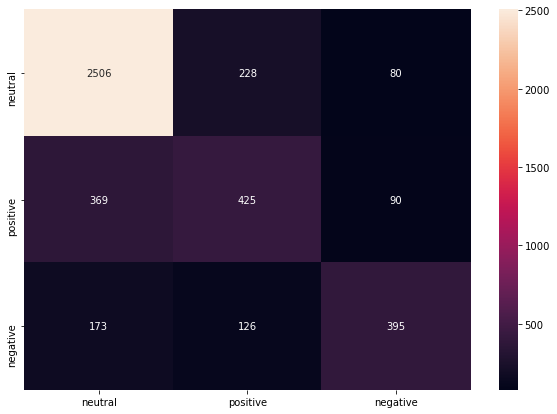

In [37]:
#Confusion Matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

conf_mat = confusion_matrix(y_test, result)

print(conf_mat)

df_cm = pd.DataFrame(conf_mat, index = [i for i in ['neutral','positive','negative']],
                  columns = [i for i in ['neutral','positive','negative']])
plt.figure(figsize = (10,7))
sns.heatmap(df_cm, annot=True, fmt='g')

### TfidfVectorizer

In [38]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=1000)
features_tfidf_vec = vectorizer.fit_transform(df['Text'])

features_tfidf_vec = features_tfidf_vec.toarray()

In [39]:
features_tfidf_vec.shape

(14640, 1000)

In [40]:
#Train-Test Split
from sklearn.model_selection import train_test_split

labels = df['airline_sentiment']

X_train, X_test, y_train, y_test = train_test_split(features_tfidf_vec, labels, test_size=0.3, random_state=42)

In [41]:
#Model
forest = RandomForestClassifier(n_estimators=10, n_jobs=4)
forest = forest.fit(X_train, y_train)

print(forest)
print(np.mean(cross_val_score(forest, features_tfidf_vec, labels, cv=10)))

RandomForestClassifier(n_estimators=10, n_jobs=4)
0.7149590163934427


In [42]:
#Prediction
result = forest.predict(X_test)

[[2607  159   48]
 [ 443  393   48]
 [ 225  117  352]]


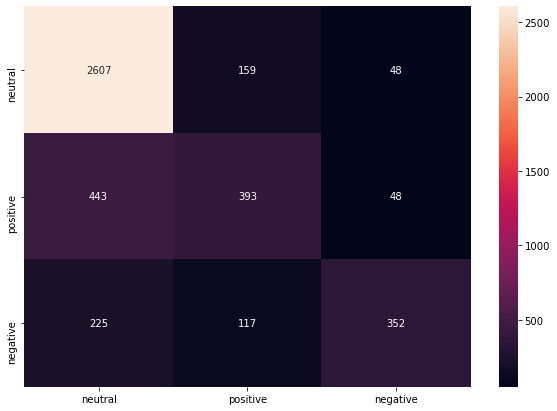

In [43]:
#Confusion Matrix
conf_mat = confusion_matrix(y_test, result)

print(conf_mat)

df_cm = pd.DataFrame(conf_mat, index = [i for i in ['neutral','positive','negative']],
                  columns = [i for i in ['neutral','positive','negative']])
plt.figure(figsize = (10,7))
sns.heatmap(df_cm, annot=True, fmt='g')

# Summary of the application of Various Pre-processing and Vectorization 

To my understanding, the purpose of the various pre-processing steps is to clean the data so that it can be made machine-understandable by the vectorizer. 
To achieve this, I first removed http links, contractions, and special characters, in that order. I found if I did those steps out of order, it could potentially mess things up. Then, I performed tokenization. I was in no particular rush to do tokenization early on because it makes some of the pre-processing steps more convoluted, requiring the use of an additional function, for loop, or some other iterator. Next, I chose to remove stopwords. We remove stopwords because they convey no additional meaning. 
I then, performed lowercasing. After that, I performed lemmatization. I did not use stemming because it just chopps off the suffix. I chose to use lemmatization because it is a more accurate way to reduce words down to their root words.

Vectorization records the frequency of occurrance of each word.
It seems like the countvectorizer performed better than the TF-IDF because there were more instances of true-positive.